<h1 style="font - size: 40px;">Expectation Decider - Probability & Statistics</h1>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import comb


pd.set_option('display.max_columns',None)
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Mathematicas\expectation_decider_dataset (1).csv")
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,14.0,82.3,Yes,70,Pass
1,11.4,84.7,Yes,59,Pass
2,14.6,91.0,Yes,58,Pass
3,18.1,90.6,No,59,Fail
4,11.1,61.5,No,71,Fail


<h1 style ="font-size:40px;"> 1. Understanding the Basics</h1>

1.Probability that a randomly select student passes.

2.Probability that a student stuides more than 10 hours per week.

3.Probability that a student participates in group discussion.

In [15]:
n = len(df)
p_pass = (df['final_exam_pass'] == 'Pass').mean()
p_study_above_10 = (df['study_hours'] > 10).mean()
p_group_yes = (df['group_discussion'] == 'yes').mean()
print('p(pass) =',p_pass)
print('p(study hours > 10) =', p_study_above_10)
print('p(Group discussion = yes) =', p_group_yes)

p(pass) = 0.495
p(study hours > 10) = 0.685
p(Group discussion = yes) = 0.0


<h1 style ="font - size 40px;">2.Empirical and Theoretical Probability</h1>

Empirical Probability is calculated from observed data.


Theoretical Probability is calculated using a mathematical model. For 3 independent selections where the probability of passing is (P), the number of passes follows a binomial distribution.

In [22]:
empirical_probability = (df['final_exam_pass'] == 'Pass').mean()
print('Empirical probability of passing =', empirical_probability)

p = empirical_probability
k = 2
n_trials = 3
theoretical_probability_exactly_2 = comb(n_trials, k) * (p ** k) * ((1-p) ** (n_trials-k))
print('Theoretical/model probability of exactly 2 passes out of 3 =', theoretical_probability_exactly_2)

Empirical probability of passing = 0.495
Theoretical/model probability of exactly 2 passes out of 3 = 0.37121287499999994


<h1 style = "font-size: 40px;">3.Random Variable and Probability </h1>

In [23]:
x_values = np.arange(0, 4)
probabilities = [comb(3, x) * p**x * (1-p)**(3-x) for x in x_values]
dist = pd.DataFrame({'X': x_values, 'P(X)': probabilities})
print(dist)
mean_x = 3 * p
variance_x = 3 * p * (1-p)
print('Mean =', mean_x)
print('Variance =', variance_x)

   X      P(X)
0  0  0.128788
1  1  0.378712
2  2  0.371213
3  3  0.121287
Mean = 1.4849999999999999
Variance = 0.749925


<h1 style="font-size: 40px;"> 4.Venn Diagram Conditions</h1>

A only          69
B only          25
Both (A ∩ B)    68
Neither         38
dtype: int64


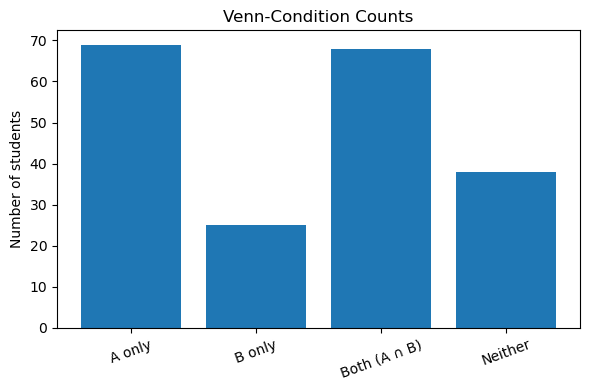

In [18]:
A = df['study_hours'] > 10
B = df['attendance'] > 80
counts = {
    'A only': (A & ~B).sum(),
    'B only': (~A & B).sum(),
    'Both (A ∩ B)': (A & B).sum(),
    'Neither': (~A & ~B).sum()
}
print(pd.Series(counts))

plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=20)
plt.ylabel('Number of students')
plt.title('Venn-Condition Counts')
plt.tight_layout()
plt.show()

<h1 style="font_size; 40px:">5.Contingency Table and Probability Calculations</h1>

In [19]:
table = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
print(table)

total = len(df)
joint_probability = ((df['group_discussion'] == 'Yes') & (df['final_exam_pass'] == 'Pass')).mean()
marginal_probability_pass = (df['final_exam_pass'] == 'Pass').mean()
conditional_probability = (
    ((df['group_discussion'] == 'Yes') & (df['final_exam_pass'] == 'Pass')).sum()
    / (df['group_discussion'] == 'Yes').sum()
)
print('Joint P(Group discussion Yes AND Pass) =', joint_probability)
print('Marginal P(Pass) =', marginal_probability_pass)
print('Conditional P(Pass | Group discussion Yes) =', conditional_probability)

final_exam_pass   Fail  Pass
group_discussion            
No                  47    32
Yes                 54    67
Joint P(Group discussion Yes AND Pass) = 0.335
Marginal P(Pass) = 0.495
Conditional P(Pass | Group discussion Yes) = 0.5537190082644629


<h1 style="font-size; 40px:"> 6.Conditional Probability and independence</h1>

In [20]:
p_pass_given_yes = conditional_probability
print('P(Pass | Yes) =', p_pass_given_yes)
print('P(Pass) =', marginal_probability_pass)
print('Independent?', np.isclose(p_pass_given_yes, marginal_probability_pass))

P(Pass | Yes) = 0.5537190082644629
P(Pass) = 0.495
Independent? False


<h1 style="font_size; 40px:"> 7.Bayes Theoren</h1>

In [21]:
p_high_given_pass = 0.70
p_high_given_fail = 0.40
p_high = 0.60
p_pass_dataset = (df['final_exam_pass'] == 'Pass').mean()
bayes_result = (p_high_given_pass * p_pass_dataset) / p_high
print('Estimated P(Pass | High attendance) =', bayes_result)

Estimated P(Pass | High attendance) = 0.5775
